## Setup

In [1]:
from gut_former.utils.fig_style import apply_style

apply_style(font_family="DejaVu Serif", base_font_size=16)

In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import pdist, squareform
from skbio.stats.composition import clr
from skbio.stats.ordination import pcoa

from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.ticker import MaxNLocator

warnings.filterwarnings("ignore", category=RuntimeWarning, module="skbio")

In [3]:
from gut_former.utils.project_paths import find_data_path, find_figures_path
from gut_former.utils.data_prep import collapse_to_genus

data_path = find_data_path()
figures_path = find_figures_path()
figures_path.mkdir(parents=True, exist_ok=True)

## Read Data

In [4]:
metadata = (
    pd.read_csv(f"{data_path}/metadata_sample.csv", low_memory=False)
    .set_index("sample_id")
    .sort_index()
)

taxonomy = pd.read_csv(f"{data_path}/taxonomy_sample.csv", index_col=0).sort_index()
pathways = pd.read_csv(f"{data_path}/pathways_sample.csv", index_col=0).sort_index()

print(f"metadata: {metadata.shape} | taxonomy: {taxonomy.shape} | pathways: {pathways.shape}")

metadata: (128, 141) | taxonomy: (128, 202) | pathways: (128, 398)


## Signatures (NMF)

In [5]:
def to_relab(x):
    """Normalize each column to sum to 1 (relative contribution)."""
    return x.div(x.sum())


N_FUNC_SIG = 8
N_TAXO_SIG = 5

# --- Functional signatures: H (pathways x signatures), W (samples x signatures) ---
H_func = pd.read_csv(f"{data_path}/H_8_sample_pathways_all.csv", index_col=0).T
H_func.index = H_func.index.str.split(":").str[0]          # short pathway id
H_func = to_relab(H_func)
H_func.columns = H_func.apply(lambda c: " & ".join(c.nlargest(2).index), axis=0)

W_func = pd.read_csv(f"{data_path}/W_train_8_sample_pathways_all.csv", index_col=0)
W_func = to_relab(W_func)
W_func.columns = H_func.columns
W_func["dominant_sig"] = W_func.T.idxmax()
EF_dict = dict(zip(W_func.index, W_func["dominant_sig"]))

# --- Taxonomic signatures: H (genus x signatures), W (samples x signatures) ---
H_taxo = pd.read_csv(f"{data_path}/H_5_sample_taxonomy_healthy.csv", index_col=0).T
H_taxo = to_relab(H_taxo)
H_taxo.columns = list(range(N_TAXO_SIG))                   # 0..4 signature ids

W_taxo = pd.read_csv(f"{data_path}/W_train_5_sample_taxonomy_healthy.csv", index_col=0)
W_taxo = W_taxo[W_taxo.index.isin(W_func.index)]
W_taxo.columns = [f"TS{i + 1}" for i in range(N_TAXO_SIG)]

# --- Signature colormap (Okabe-Ito palette) ---
colors = [
    "#0072B2", "#E69F00", "#009E73", "#D55E00",
    "#CC79A7", "#56B4E9", "#7A7A00", "#666666",
]
signatures_cmap = dict(zip(H_func.columns, colors))

# Supplementary Figure 2A - Sample x Signature Weights

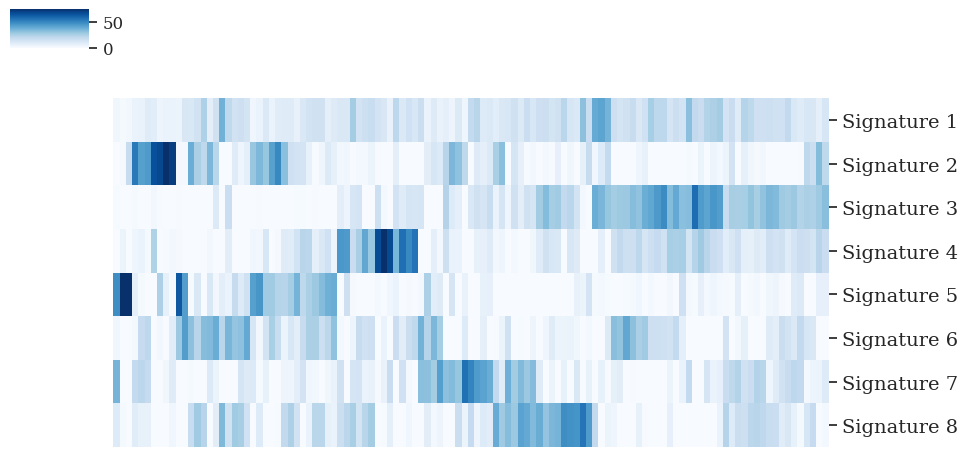

In [6]:
W_func_heatmap = W_func.drop(columns="dominant_sig").copy()
W_func_heatmap.columns = [f"Signature {i + 1}" for i in range(N_FUNC_SIG)]
W_func_heatmap = W_func_heatmap.div(W_func_heatmap.sum(axis=1), axis=0)

g = sns.clustermap(
    W_func_heatmap.T * 100, cmap="Blues", xticklabels=False,
    cbar_kws={"shrink": 0.2}, figsize=(10, 5), row_cluster=False, col_cluster=True,
    vmin=0, vmax=75, dendrogram_ratio=0.1, cbar_pos=(0.02, 0.83, 0.03, 0.15),
)
g.ax_heatmap.tick_params(axis="both", which="major", labelsize=14)
g.ax_col_dendrogram.set_visible(False)
plt.tight_layout()
plt.savefig(f"{figures_path}/sFig2A.png", dpi=300, bbox_inches="tight")
plt.show()

# Supplementary Figure 2B - Signature Abundance by Disease

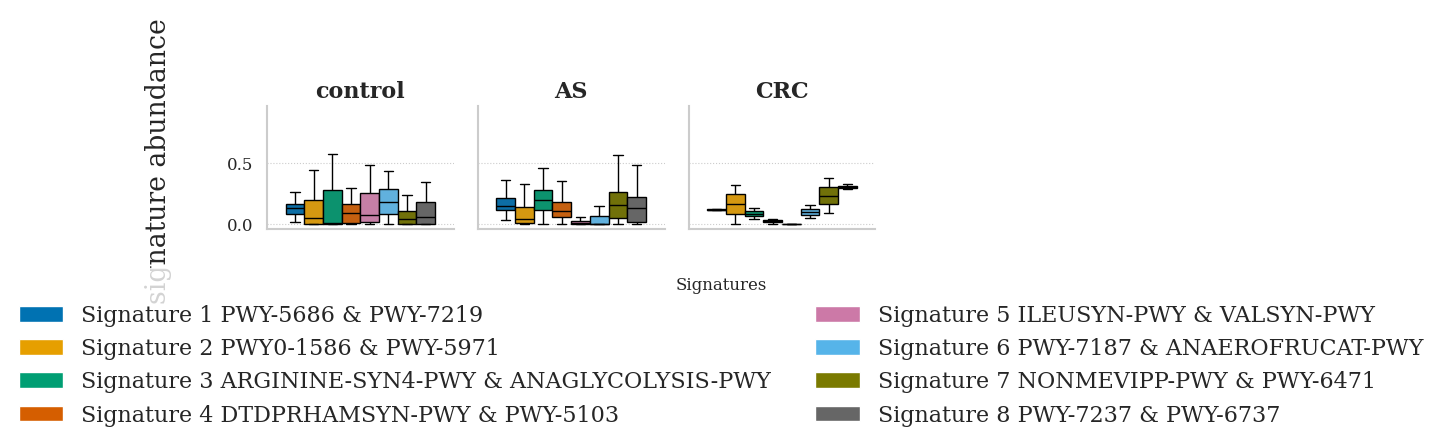

In [7]:
study_condition_dict = dict(zip(metadata.index, metadata["study_condition"]))

W_disease = W_func.drop(columns="dominant_sig").copy()
W_disease = W_disease.div(W_disease.sum(axis=1), axis=0)
W_disease["disease"] = W_disease.index.map(study_condition_dict)
df = W_disease.set_index("disease").stack().reset_index()

diseases = [d for d in df.disease.unique()
            if d not in ["FMT", "carcinoma_surgery_history"] and pd.notna(d)]

n_cols = 5
n_rows = (len(diseases) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 2), sharey=True)
axes = axes.flatten()

for i, disease in enumerate(diseases):
    d_df = df[df["disease"] == disease]
    sns.boxplot(data=d_df, hue="level_1", y=0, ax=axes[i], fliersize=0,
                palette=signatures_cmap, linewidth=1, saturation=0.85,
                boxprops=dict(edgecolor="black"), whiskerprops=dict(color="black"),
                capprops=dict(color="black"), medianprops=dict(color="black"))
    axes[i].set_title(disease.replace("_", " "), weight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()
    axes[i].grid(axis="y", lw=0.8, linestyle=":")
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

for i in range(len(diseases), len(axes)):
    axes[i].set_visible(False)

fig.supylabel("signature abundance \n")
legend_elements = [Patch(facecolor=signatures_cmap[sig], label=f"Signature {i + 1} {sig}")
                   for i, sig in enumerate(H_func.columns)]
fig.legend(handles=legend_elements, title="Signatures", bbox_to_anchor=(0.5, 0.0),
           loc="upper center", ncol=max(1, len(legend_elements) // 3), edgecolor="w")

plt.tight_layout()
plt.savefig(f"{figures_path}/sFig2B.png", dpi=300, bbox_inches="tight")
plt.show()

# Supplementary Figure 2C - Genus PCoA by Enterotype

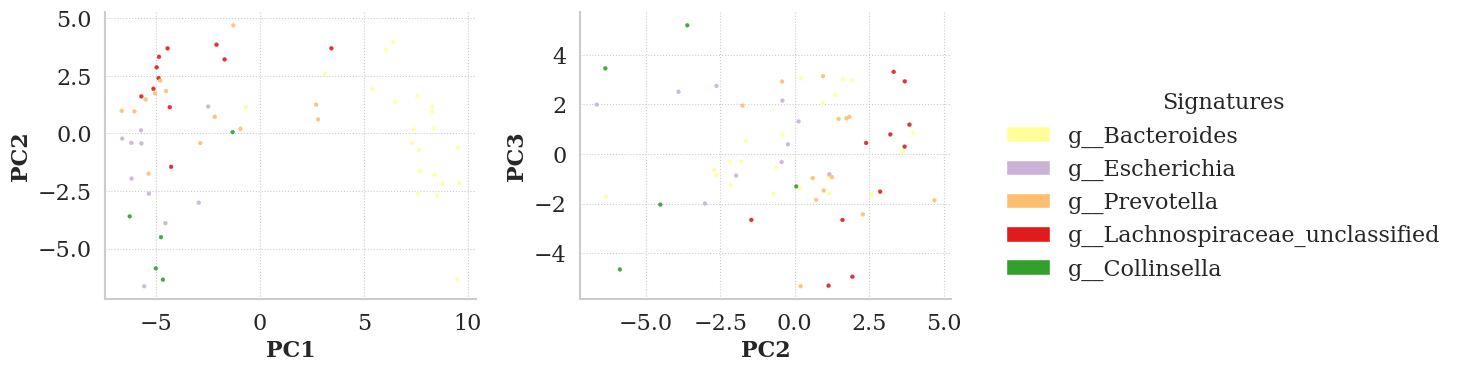

In [8]:
FSIZE = 16

# Enterotype = dominant taxonomic signature, named by its top genus
H_taxo_ent = H_taxo.copy()
H_taxo_ent.columns = H_taxo_ent.idxmax()          # name each signature by top genus
W_taxo_ent = W_taxo.copy()
W_taxo_ent.columns = H_taxo_ent.columns
ET_dict = dict(zip(W_taxo_ent.index, W_taxo_ent.T.idxmax()))

ETcolors = ["#ffff99", "#cab2d6", "#fdbf6f", "#e31a1c", "#33a02c", "#1f78b4", "#ff7f00"]
ETcmap = dict(zip(H_taxo_ent.columns, ETcolors))

healthy_idx = metadata.index[metadata["study_condition"] == "control"]
genus = collapse_to_genus(taxonomy.loc[taxonomy.index.isin(healthy_idx)])
common = genus.index.intersection(W_taxo_ent.index)
genus = genus.loc[common]

genus_clr = clr(genus + 1e-3)
pcoa_df = pcoa(squareform(pdist(genus_clr))).samples
pcoa_df.index = common
pcoa_df["signature"] = pcoa_df.index.map(ET_dict)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_params = dict(s=8, hue="signature", palette=ETcmap, edgecolor=None, alpha=0.9, legend=False)
sns.scatterplot(data=pcoa_df, x="PC1", y="PC2", ax=axes[0], **plot_params)
sns.scatterplot(data=pcoa_df, x="PC2", y="PC3", ax=axes[1], **plot_params)

axes[0].set_xlabel("PC1", fontsize=FSIZE, weight="bold")
axes[0].set_ylabel("PC2", fontsize=FSIZE, weight="bold")
axes[1].set_xlabel("PC2", fontsize=FSIZE, weight="bold")
axes[1].set_ylabel("PC3", fontsize=FSIZE, weight="bold")
for ax in axes:
    ax.set_axisbelow(True)
    ax.grid(axis="both", linewidth=0.8, linestyle=":", which="major")
    ax.tick_params(axis="both", labelsize=FSIZE)
    sns.despine(ax=ax, top=True, right=True)

legend_elements = [Patch(facecolor=ETcmap[sig], label=sig) for sig in H_taxo_ent.columns]
fig.legend(handles=legend_elements, title="Signatures", title_fontsize=FSIZE, fontsize=FSIZE,
           bbox_to_anchor=(1.0, 0.5), loc="center left", edgecolor="w")

plt.tight_layout()
plt.savefig(f"{figures_path}/sFig2C.png", dpi=300, bbox_inches="tight")
plt.show()

# Supplementary Figure 2 - Per-Signature Pathway Distributions (PDF)

In [9]:
from matplotlib.backends.backend_pdf import PdfPages

A4_W, A4_H = 8.27, 11.69
BARS_PER_PAGE = 50


def plot_signature_pdf(sig, out_path):
    values = (H_func[sig] * 100)
    values = values[values > 0].sort_values(ascending=False)
    color = signatures_cmap[sig]
    chunks = [values.iloc[i:i + BARS_PER_PAGE] for i in range(0, len(values), BARS_PER_PAGE)]

    with PdfPages(out_path) as pdf:
        for page, chunk in enumerate(chunks, start=1):
            fig, ax = plt.subplots(1, 1, figsize=(A4_W, A4_H))
            ax.barh(range(len(chunk)), chunk.values, color=color,
                    edgecolor="white", linewidth=0.5, alpha=0.85, height=0.7)
            ax.set_yticks(range(len(chunk)))
            ax.set_yticklabels(chunk.index, fontsize=8)
            ax.set_xlim(0, values.max() * 1.05)
            ax.set_ylim(-0.5, len(chunk) - 0.5)
            ax.invert_yaxis()
            ax.set_title(f"Signature — {sig}  (page {page}/{len(chunks)})",
                         fontsize=11, fontweight="bold", color=color, pad=6)
            ax.set_xlabel("Weight (%)", fontsize=9)
            ax.tick_params(axis="x", labelsize=8)
            ax.grid(axis="x", alpha=0.2, linestyle="--")
            ax.set_axisbelow(True)
            for spine in ["top", "right", "left"]:
                ax.spines[spine].set_visible(False)
            ax.spines["bottom"].set_linewidth(0.5)
            plt.tight_layout(pad=1.0)
            pdf.savefig(fig)
            plt.close(fig)


for i, sig in enumerate(H_func.columns, start=1):
    out_path = f"{figures_path}/sFig2_signature_{i}.pdf"
    plot_signature_pdf(sig, out_path)
    print(f"Saved {out_path}")

Saved /Users/wojciechnowak/Sano/microbiomeGPT/figures/sFig2_signature_1.pdf


Saved /Users/wojciechnowak/Sano/microbiomeGPT/figures/sFig2_signature_2.pdf


Saved /Users/wojciechnowak/Sano/microbiomeGPT/figures/sFig2_signature_3.pdf


Saved /Users/wojciechnowak/Sano/microbiomeGPT/figures/sFig2_signature_4.pdf


Saved /Users/wojciechnowak/Sano/microbiomeGPT/figures/sFig2_signature_5.pdf


Saved /Users/wojciechnowak/Sano/microbiomeGPT/figures/sFig2_signature_6.pdf


Saved /Users/wojciechnowak/Sano/microbiomeGPT/figures/sFig2_signature_7.pdf


Saved /Users/wojciechnowak/Sano/microbiomeGPT/figures/sFig2_signature_8.pdf
